In [2]:
!pip install requests beautifulsoup4 pandas pymongo scikit-learn


Defaulting to user installation because normal site-packages is not writeable


Number of features: 10


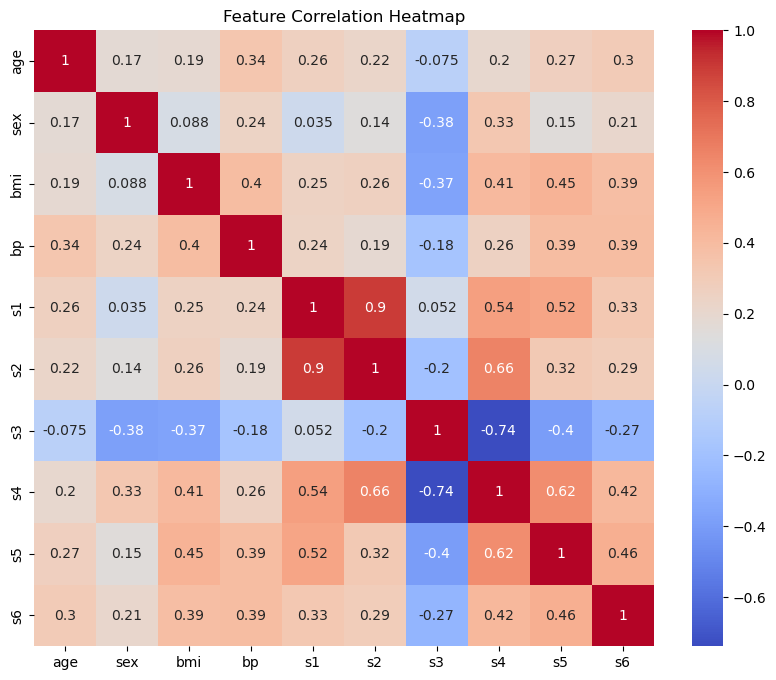

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


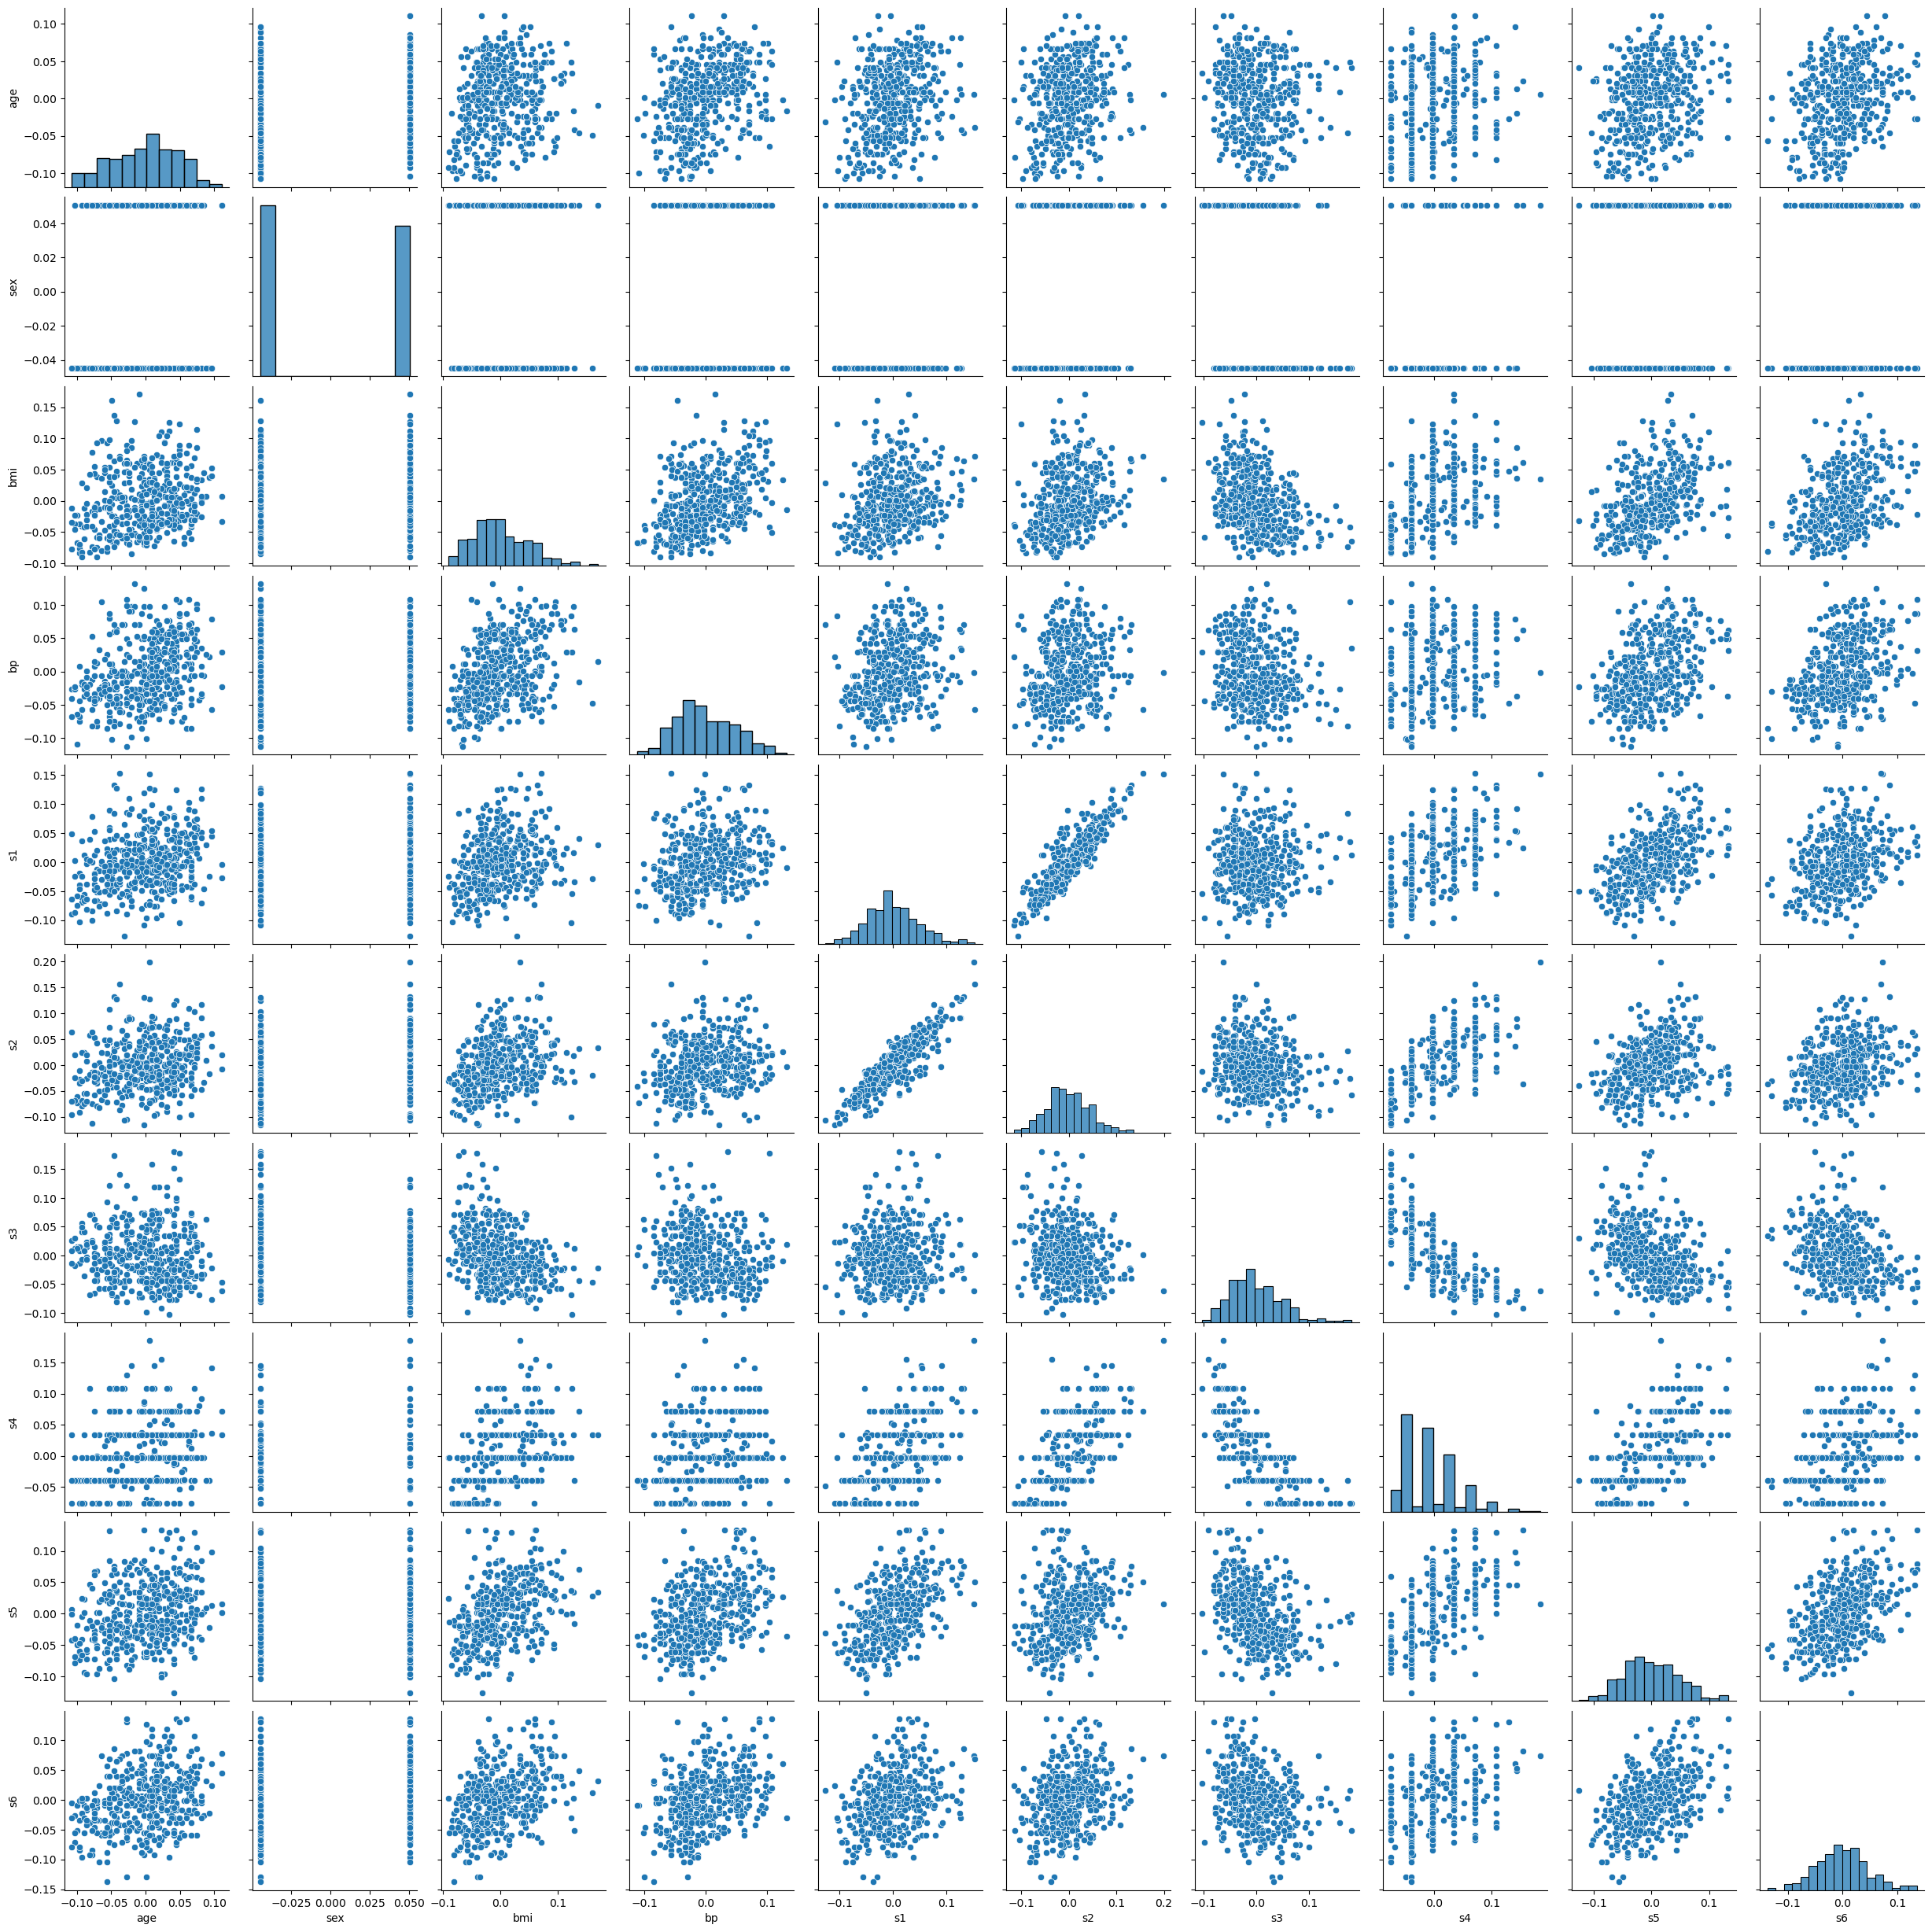

In [21]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


diabetes = load_diabetes()
X = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y = pd.Series(diabetes.target, name="target")

# (a) number of features
print(f"Number of features: {X.shape[1]}")

# heatmap 
plt.figure(figsize=(10, 8))
sns.heatmap(X.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

# pairplot
sns.pairplot(X)
plt.show()


In [11]:
# (b)
print("Missing values per column:\n", df.isnull().sum())


imputer = SimpleImputer(strategy='mean')
df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)


print("Missing values after imputation:\n", df_imputed.isnull().sum())


Missing values per column:
 age    0
sex    0
bmi    0
bp     0
s1     0
s2     0
s3     0
s4     0
s5     0
s6     0
dtype: int64
Missing values after imputation:
 age    0
sex    0
bmi    0
bp     0
s1     0
s2     0
s3     0
s4     0
s5     0
s6     0
dtype: int64


In [16]:

# (c) 
for train_size, test_size in [(0.4, 0.6), (0.8, 0.2)]:
    
    X_train, X_test, y_train, y_test = train_test_split(X_imputed, y, test_size=test_size, random_state=42)
    
    
    knn = KNeighborsClassifier()
    knn.fit(X_train, y_train)
    y_pred_knn = knn.predict(X_test)

    nb = GaussianNB()
    nb.fit(X_train, y_train)
    y_pred_nb = nb.predict(X_test)
    
    
    metrics = {
        'Train Size': train_size,
        'Test Size': test_size,
        'KNN Accuracy': accuracy_score(y_test, y_pred_knn),
        'KNN Precision': precision_score(y_test, y_pred_knn, average='weighted', zero_division=1),
        'KNN Recall': recall_score(y_test, y_pred_knn, average='weighted', zero_division=1),
        'KNN F1': f1_score(y_test, y_pred_knn, average='weighted'),
        'NB Accuracy': accuracy_score(y_test, y_pred_nb),
        'NB Precision': precision_score(y_test, y_pred_nb, average='weighted', zero_division=1),
        'NB Recall': recall_score(y_test, y_pred_nb, average='weighted', zero_division=1),
        'NB F1': f1_score(y_test, y_pred_nb, average='weighted')
    }
    results.append(metrics)


results_df = pd.DataFrame(results)


In [17]:
results_df

,Train Size,Test Size,KNN Accuracy,KNN Precision,KNN Recall,KNN F1,NB Accuracy,NB Precision,NB Recall,NB F1
0,0.4,0.6,0.0,0.766917,0.0,0.0,0.0,0.936090,0.0,0.0
1,0.8,0.2,0.0,0.797753,0.0,0.0,0.0,0.876404,0.0,0.0


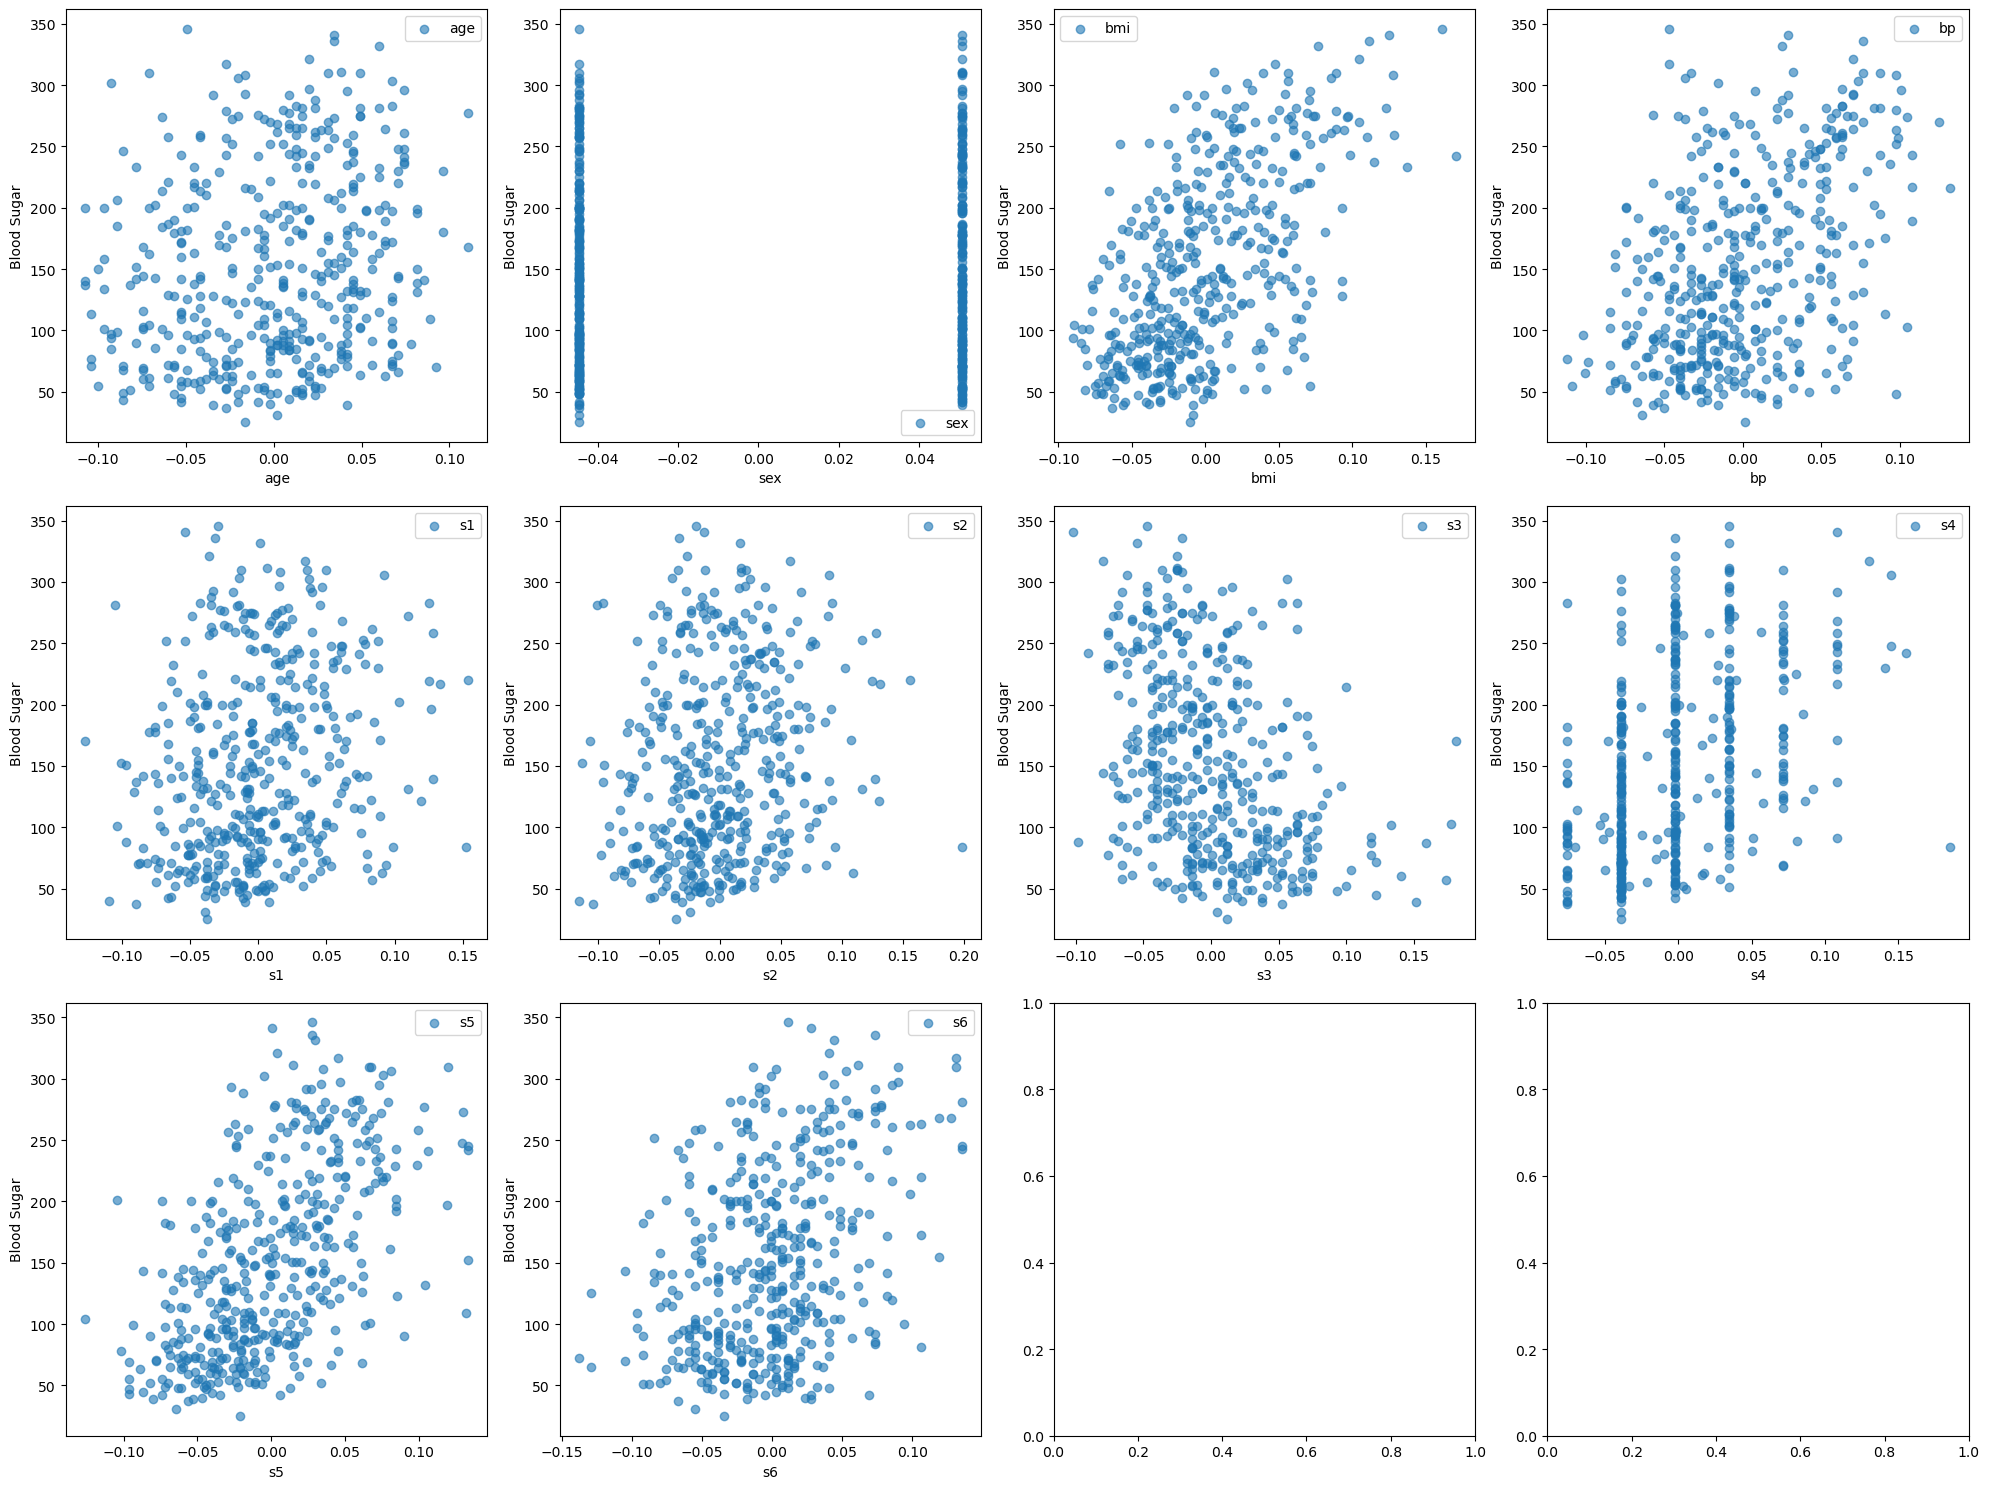

In [19]:
# (d) 
fig, axes = plt.subplots(3, 4, figsize=(20, 15))
axes = axes.flatten()
for i, col in enumerate(X.columns):
    axes[i].scatter(X_imputed[col], y, alpha=0.6, label=col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Blood Sugar")
    axes[i].legend()
plt.tight_layout()
plt.show()